# Tutorial 2 — Backends and Batching

**What you will learn**
- The different solvers (backends) torchmatch ships and when each wins
- How to solve a batch of problems at once with a 3-D cost tensor
- The unpacked output format for tracking pipelines
- GPU vs CPU: when crossing the device boundary is worth it

**Prerequisites** — Tutorial 1, or familiarity with `torchmatch.assignment.solve`.

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchmatch
from torchmatch.assignment import Backend

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
CUDA = torch.cuda.is_available()
device_label = "CUDA" if CUDA else "CPU only"
print(f"torchmatch {torchmatch.__version__}  |  CUDA available: {CUDA}")

torchmatch 1.0.0  |  CUDA available: True


## 1  The AUTO dispatcher

`torchmatch.assignment.solve(cost)` uses `Backend.AUTO` by default.
AUTO inspects the input at call time — device, shape, problem size — and
picks the fastest registered op.

| Situation | AUTO picks |
|-----------|-----------|
| CPU, N×M ≤ 64 | `jonker_scalar` (sequential, zero overhead) |
| CPU, square, smooth | `jonker_compact` (AVX2-gather) |
| CPU, rectangular or large | `jonker_dense` (AVX2 flat-pointer) |
| CUDA, N < 32 | `munkres` (single-path Hungarian) |
| CUDA, N ≥ 32 | `lawler` (parallel BFS Hungarian) |
| CUDA, batched, K ≤ 64 | `jonker_dense_batch` CUDA backend |

You rarely need to specify a backend explicitly.  The sections below show
*when* explicit pinning is useful (benchmarking, debugging, or overriding a
heuristic for a specific distribution).

In [2]:
rng = np.random.default_rng(0)
N = 64

cost_cpu = torch.tensor(rng.random((N, N), dtype=np.float32))

# AUTO selects the backend; solve() returns int64 row→col indices
row_to_col = torchmatch.assignment.solve(cost_cpu)
print("Shape:", row_to_col.shape, "  dtype:", row_to_col.dtype)
total_cost = cost_cpu[torch.arange(N), row_to_col].sum().item()
print(f"Total cost (N={N}): {total_cost:.4f}")

Shape: torch.Size([64])   dtype: torch.int64
Total cost (N=64): 1.5033


## 2  Calling a backend directly

Every backend is also accessible via `torchmatch.assignment.ops.<name>`.
Use it to pin a specific variant for benchmarking or to exploit a known property of your cost distribution.

In [3]:
# All three CPU JV variants produce the same optimal cost
for op_name in ("jonker_scalar", "jonker_dense", "jonker_compact"):
    op = getattr(torchmatch.assignment.ops, op_name)
    result = op(cost_cpu)
    cost = cost_cpu[torch.arange(N), result].sum().item()
    print(f"{op_name:20s}  total cost = {cost:.6f}")

jonker_scalar         total cost = 1.503263
jonker_dense          total cost = 1.503263
jonker_compact        total cost = 1.503263


On tied cost matrices multiple optimal assignments exist; the specific
indices may differ between backends but the total cost is always the same.

## 3  Performance by problem size

`jonker_compact` is 20–30 % faster than `jonker_dense` for small, square,
smooth-cost problems; `jonker_dense` wins for rectangular inputs or very
large N.  Below we time both on random uniform costs.

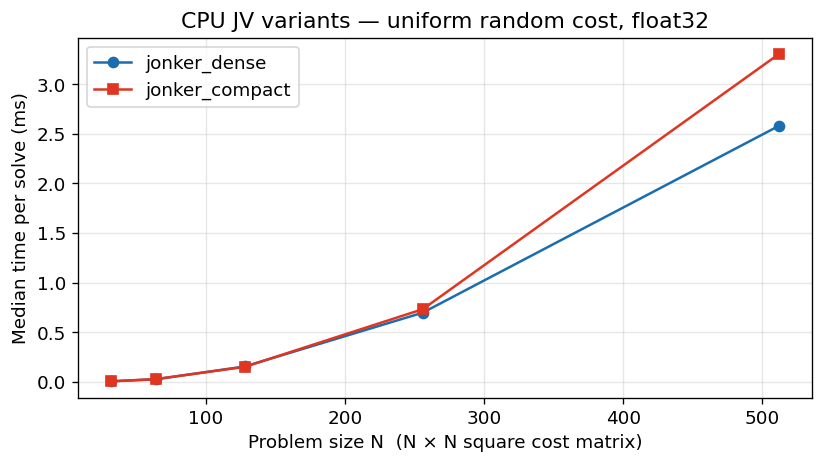

In [4]:
def time_op(op, cost, n_repeats=50):
    # warm-up
    for _ in range(5):
        op(cost)
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        op(cost)
    return (time.perf_counter() - t0) / n_repeats * 1e3  # ms


sizes = [32, 64, 128, 256, 512]
results_dense = []
results_compact = []

for n in sizes:
    c = torch.tensor(rng.random((n, n), dtype=np.float32))
    results_dense.append(time_op(torchmatch.assignment.ops.jonker_dense, c))
    results_compact.append(time_op(torchmatch.assignment.ops.jonker_compact, c))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, results_dense, "o-", label="jonker_dense", color="#1a6daf")
ax.plot(sizes, results_compact, "s-", label="jonker_compact", color="#E03520")
ax.set_xlabel("Problem size N  (N × N square cost matrix)")
ax.set_ylabel("Median time per solve (ms)")
ax.set_title("CPU JV variants — uniform random cost, float32")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4  Batched solving

A 3-D tensor `(B, N, M)` stacks B independent problems.  `solve` distributes
them across CPU threads (via `at::parallel_for`) or launches a single tiled
CUDA kernel.  This is the main entry point for tracking pipelines where you
need to solve one assignment per video frame per mini-batch.

In [5]:
B, N = 32, 48  # 32 frames, 48 tracks/detections each
costs_batch = torch.rand(B, N, N)

# returns shape (B, N)
assignments = torchmatch.assignment.solve(costs_batch)
print("Batch input:", costs_batch.shape)
print("Output    :", assignments.shape)
print("All rows matched:", (assignments >= 0).all().item())

Batch input: torch.Size([32, 48, 48])
Output    : torch.Size([32, 48])
All rows matched: True


### Unpacked output

Tracker pipelines need three things after assignment:
1. The matched (track, detection) pairs
2. Which tracks have no matching detection (lost tracks)
3. Which detections have no matching track (new objects)

`unpack=True` returns all three directly, avoiding a Python loop over the
row-to-col index tensor.

In [6]:
matches, unmatched_rows, unmatched_cols, n_matched = torchmatch.assignment.solve(
    costs_batch, unpack=True
)
print("matches shape      :", matches.shape, "  (B, N, 2) — padded (row, col) pairs")
print("unmatched_rows     :", unmatched_rows.shape, "  (B, N) — padded row indices")
print("unmatched_cols     :", unmatched_cols.shape, "  (B, M)")
print("n_matched          :", n_matched.shape, "  (B,) — valid entries per batch")
print("First batch: matched", n_matched[0].item(), "of", N, "pairs")

matches shape      : torch.Size([32, 48, 2])   (B, N, 2) — padded (row, col) pairs
unmatched_rows     : torch.Size([32, 48])   (B, N) — padded row indices
unmatched_cols     : torch.Size([32, 48])   (B, M)
n_matched          : torch.Size([32])   (B,) — valid entries per batch
First batch: matched 48 of 48 pairs


In [7]:
# Reconstruct per-batch pairs manually to verify
b = 0
k = n_matched[b].item()
valid_matches = matches[b, :k]  # shape (k, 2)
print(f"Batch {b}: {k} matched pairs")
print("First 5 pairs (track_idx, det_idx):", valid_matches[:5].tolist())

Batch 0: 48 matched pairs
First 5 pairs (track_idx, det_idx): [[0, 34], [1, 42], [2, 31], [3, 12], [4, 29]]


## 5  When to use CUDA

The CUDA Hungarian ops (`munkres`, `lawler`) are faster than the CPU JV ops
**only** in the regime of integer-tied (quantised) costs at large N.  For
smooth floating-point costs the CPU AVX2 kernels typically win by 10–100×
because the CUDA ops synchronise with the host mid-execution.

The CUDA backend of `jonker_dense_batch` is the exception: it runs a
shared-memory tiled kernel with no host syncs, so it wins for batches of
small square problems (K ≤ 64).

In [8]:
if CUDA:
    K = 48  # must be ≤ 64 for the CUDA tiled kernel
    B_large = 128

    costs_gpu = torch.rand(B_large, K, K, device="cuda")

    def timed_cuda(fn, *args, n=20):
        # warm-up
        for _ in range(5):
            fn(*args)
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n):
            fn(*args)
        torch.cuda.synchronize()
        return (time.perf_counter() - t0) / n * 1e3

    costs_cpu_b = costs_gpu.cpu()

    t_gpu = timed_cuda(torchmatch.assignment.solve, costs_gpu)
    t_cpu = time_op(torchmatch.assignment.solve, costs_cpu_b)

    print(f"Batched solve  B={B_large} K={K}:")
    print(f"  CUDA jonker_dense_batch : {t_gpu:.2f} ms")
    print(f"  CPU  jonker_dense_batch : {t_cpu:.2f} ms")
    print(f"  GPU speedup: {t_cpu / t_gpu:.1f}×")
else:
    print("CUDA not available — GPU comparison skipped.")
    print("On a typical GPU the CUDA tiled kernel is 3–10× faster for B=128, K=48.")

Batched solve  B=128 K=48:
  CUDA jonker_dense_batch : 2.61 ms
  CPU  jonker_dense_batch : 4.13 ms
  GPU speedup: 1.6×


## Summary

- `Backend.AUTO` picks the right solver for device, shape, and size.
  Explicit backend pinning is for benchmarking or special distributions.
- Three CPU JV variants: `jonker_scalar` (sequential), `jonker_dense`
  (AVX2 rectangular), `jonker_compact` (AVX2 square, 20–30 % faster at N ≤ 256).
- Batched 3-D input: `solve(costs)` uses `at::parallel_for` on CPU or a
  tiled CUDA kernel when data is on GPU and K ≤ 64.
- `unpack=True` returns matched pairs, unmatched rows, and unmatched
  columns without Python-level iteration.

**Next**: [Tutorial 3 — Object Tracking](03_object_tracking.ipynb) builds a
complete SORT-style multi-object tracker on synthetic video data.